In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [52]:
df=pd.read_csv('student_marks.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Study_Hours,Marks
0,0,0,3.745401,16.591606
1,1,1,9.507143,30.850740
2,2,2,7.319939,27.720214
3,3,3,5.986585,24.180926
4,4,4,1.560186,10.800140


In [53]:
df.shape

(1000, 4)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  1000 non-null   int64  
 1   Unnamed: 0    1000 non-null   int64  
 2   Study_Hours   1000 non-null   float64
 3   Marks         1000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 31.4 KB


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Study_Hours     0
Marks           0
dtype: int64

In [57]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Study_Hours', 'Marks'], dtype='str')

In [58]:
df=df[['Study_Hours','Marks']]
df

,Study_Hours,Marks
0,3.745401,16.591606
1,9.507143,30.850740
2,7.319939,27.720214
3,5.986585,24.180926
4,1.560186,10.800140
...,...,...
995,0.915821,5.107417
996,9.173136,31.295869
997,1.368186,9.030485
998,9.502374,32.648516


Text(0.5, 1.0, 'study hours vs marks')

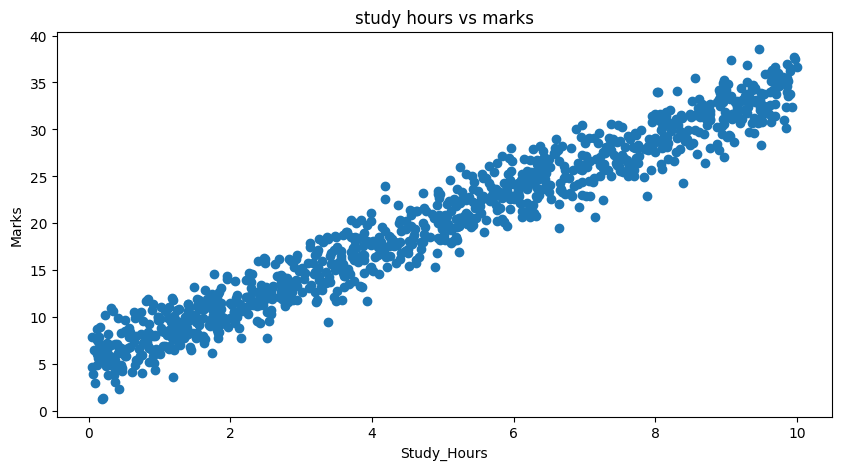

In [59]:
plt.figure(figsize=(10,5))

plt.scatter(df['Study_Hours'],df['Marks'])
plt.xlabel('Study_Hours')

plt.ylabel('Marks')
plt.title('study hours vs marks')

In [60]:

X=df[['Study_Hours']]#features/independent
Y=df['Marks']#target/dependent
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


x_train.shape

(700, 1)

In [61]:
y_train.shape

(700,)

In [62]:
 y_train

541    24.244625
440     5.169935
482    19.713744
422     7.980778
778    29.586473
         ...    
106    18.479344
270    28.029709
860    28.314267
435    28.524558
102    13.451801
Name: Marks, Length: 700, dtype: float64

In [63]:
model=LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
 model.coef_

array([2.96471706])

In [65]:
model.intercept_

np.float64(5.415581781582404)

In [70]:
y_pred=model.predict(x_test)
y_pred

array([16.707918  , 29.62544469, 19.13272833, 15.97284217, 33.58223102,
       34.15763713, 19.12842743, 31.09192568,  7.36365703, 20.79625586,
       30.28653649, 28.28156535, 21.20617676, 11.78795586,  8.90656823,
        7.95066779, 31.80172201,  8.50210667, 14.65725911, 12.83457568,
       28.31263692, 24.54312958,  5.95580736, 13.52132789, 21.68398606,
       26.83424291, 24.28334983, 25.82476509, 10.79462908, 32.09858802,
       24.24431161, 34.226171  , 11.62219689, 34.65393999,  8.40336438,
       31.71518436, 13.71616974, 24.19412498,  6.20218656, 15.06070561,
       17.85553643, 20.91313116,  6.1671596 ,  6.34007351,  7.94589264,
       24.68517334, 18.0219591 , 13.6749971 ,  7.82734296, 16.15953554,
       20.65391586, 11.99642834, 34.7678772 , 20.00543749, 16.27717386,
       23.42756767, 13.62422066,  6.0258538 , 22.26432391, 29.21791496,
       28.24371203, 23.14162447, 12.19419405, 10.18308552,  8.99209404,
       20.46479329, 23.37509121, 10.01801584, 28.31045422, 25.32

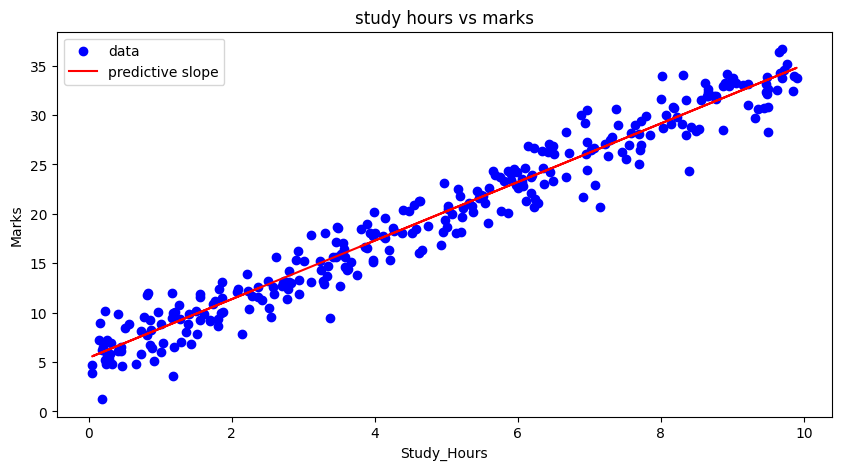

In [75]:
plt.figure(figsize=(10,5))

plt.scatter(x_test,y_test,color='blue',label='data')
plt.plot(x_test,y_pred,color='red',label='predictive slope')
plt.xlabel('Study_Hours')

plt.ylabel('Marks')
plt.title('study hours vs marks')
plt.legend()
plt.show()

In [78]:
from    sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9535717978415206

In [79]:
y_train_pred=model.predict(x_train)
r2_score(y_train,y_train_pred)

0.9493298942626006

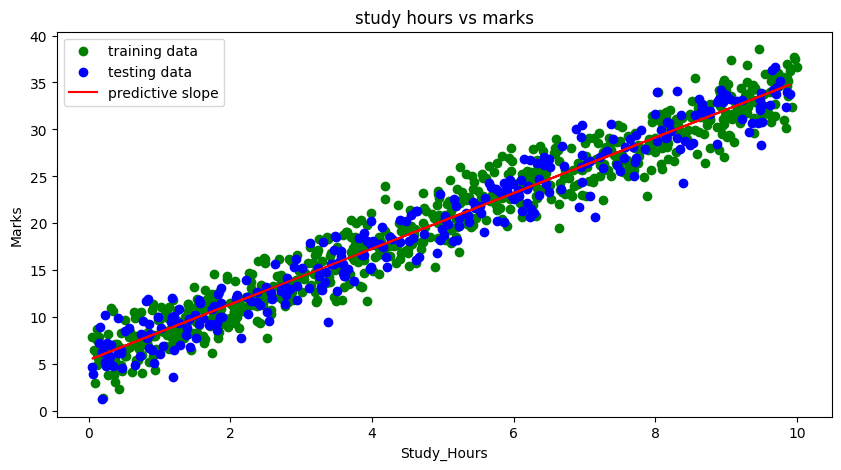

In [81]:
plt.figure(figsize=(10,5))
plt.scatter(x_train,y_train,color='green',label='training data')

plt.scatter(x_test,y_test,color='blue',label='testing data')
plt.plot(x_test,y_pred,color='red',label='predictive slope')
plt.xlabel('Study_Hours')

plt.ylabel('Marks')
plt.title('study hours vs marks')
plt.legend()
plt.show()